# El Mar de Aral se secó y empezó a exhalar carbono

Un lago se seca. El agua se va, queda el barro, y ese barro —cargado de miles de años de materia orgánica— empieza a soltar dióxido de carbono al aire.

¿Cuánto? Desde 1960, el lecho seco del Mar de Aral ha liberado unos **204 teragramos de carbono** (±53). Eso es como quemar el carbono de un país entero, en cámara lenta, durante 60 años.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

---

**Paper:** *Drying of the Aral Sea reshapes the anthropogenic carbon inventory of Central Asia* · Marcé et al., **Science** (2026)
**DOI:** [10.1126/science.aeb2344](https://doi.org/10.1126/science.aeb2344)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-16-mar-aral-carbono/notebook.ipynb)

## De dónde salen estos datos

El Mar de Aral, en Asia Central, era el cuarto lago más grande del mundo. A partir de 1960 lo desviaron para regar campos de algodón, y se fue secando hasta casi desaparecer. Es el lago más grande que se ha secado en la historia registrada.

El equipo hizo tres cosas sobre ese lecho ahora expuesto:

- **Cámaras de flujo (IRGA)** — midieron cuánto CO₂ sale del sedimento seco, sitio por sitio.
- **Núcleos de sedimento** — sacaron cilindros de barro para medir cuánto carbono orgánico guardaban.
- **Teledetección** — reconstruyeron, año a año, cuánta superficie de lecho quedó al descubierto.

Con esas tres piezas armaron la cuenta del carbono. Abramos los datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_FUENTE = 0.0          # µmol/m²/s: por encima, el sedimento EMITE (fuente)
ANIO_INICIO = 1960           # cuando arrancó el desvío del agua
FUENTE = 'Fuente: Marcé et al. (2026), Science | Datos: Zenodo 10.5281/zenodo.16809289'
COLOR_DATOS = '#2563EB'      # azul CaM
COLOR_ALERTA = '#DC2626'     # rojo
COLOR_SECUNDARIO = '#059669' # emerald
COLOR_REFERENCIA = '#D97706' # amber

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los cuatro CSV
flujo = pd.read_csv('datos/flujo_co2_sitios.csv')
area = pd.read_csv('datos/desecacion_area.csv')
reflooding = pd.read_csv('datos/reflooding_escenarios.csv')
sedimento = pd.read_csv('datos/carbono_organico_sedimento.csv')

print(f'Flujo CO2:   {len(flujo)} mediciones en {flujo.sitio.nunique()} sitios')
print(f'Desecación:  {len(area)} años ({area.anio.min()}-{area.anio.max()})')
print(f'Reflooding:  {len(reflooding)} escenarios de reinundación')
print(f'Sedimento:   {len(sedimento)} muestras de carbono orgánico')

Flujo CO2:   111 mediciones en 14 sitios
Desecación:  63 años (1960-2022)
Reflooding:  4 escenarios de reinundación
Sedimento:   554 muestras de carbono orgánico


## Primero, cuánto lago se secó

Aquí está.

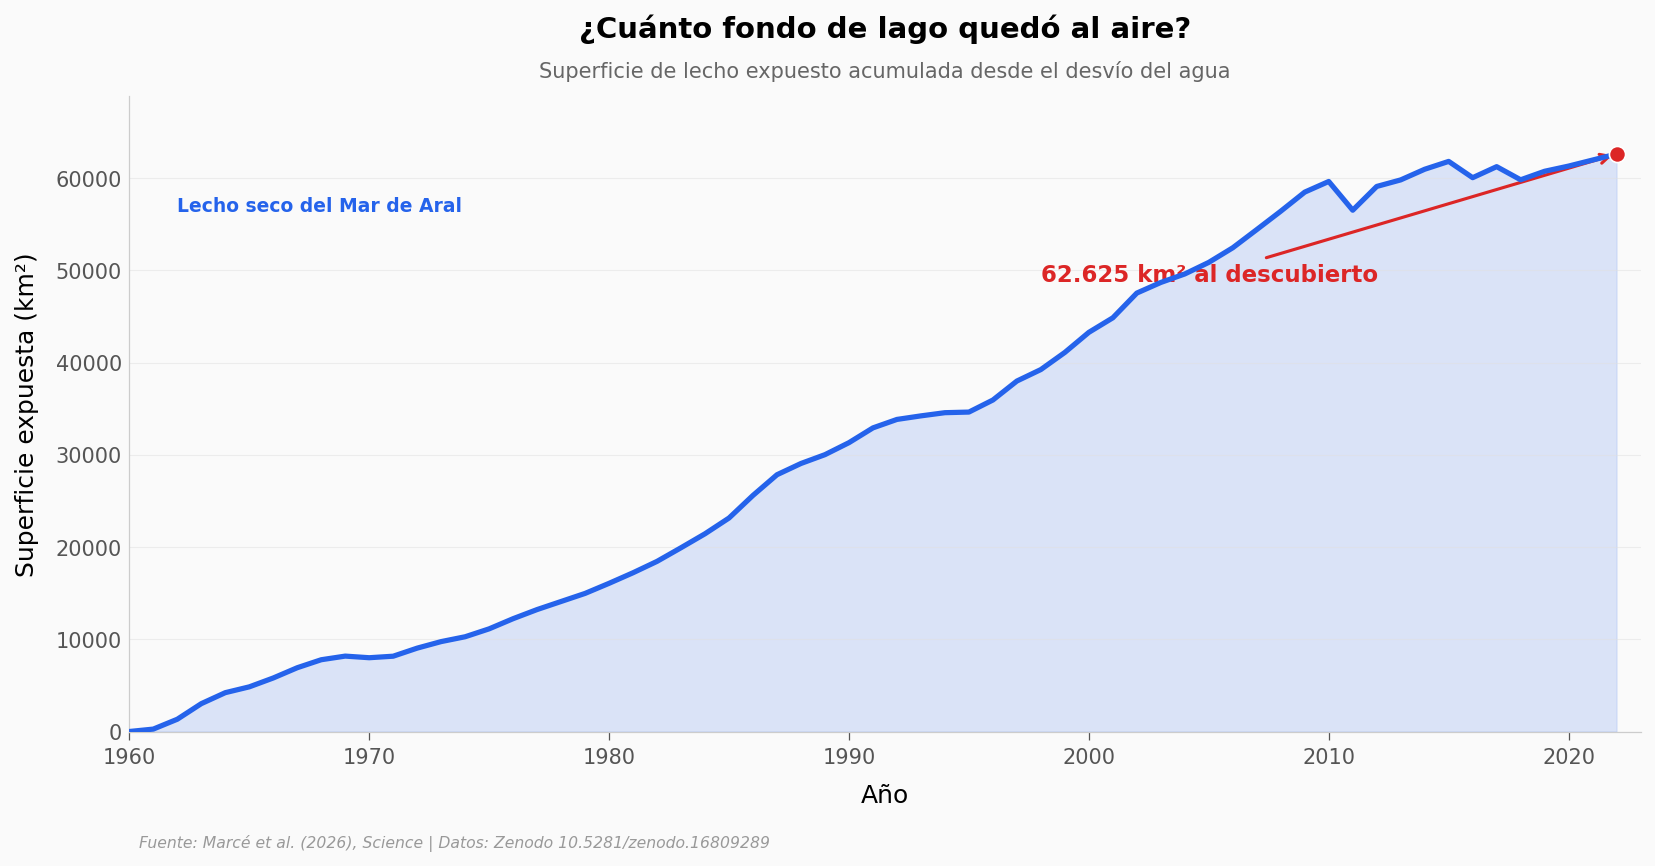

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.fill_between(area.anio, 0, area.area_expuesta_acum_km2,
                color=COLOR_DATOS, alpha=0.15)
ax.plot(area.anio, area.area_expuesta_acum_km2,
        color=COLOR_DATOS, linewidth=2.5, zorder=5)

# Valor final destacado
area_2022 = area.loc[area.anio == 2022, 'area_expuesta_acum_km2'].iloc[0]
ax.scatter([2022], [area_2022], color=COLOR_ALERTA, s=60,
           edgecolors='white', linewidths=0.8, zorder=6)
ax.annotate(f'{area_2022:,.0f} km² al descubierto'.replace(',', '.'),
            xy=(2022, area_2022), xytext=(1998, area_2022*0.78),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.text(1962, area_2022*0.9, 'Lecho seco del Mar de Aral', fontsize=9,
        color=COLOR_DATOS, fontweight='bold', ha='left')

ax.set_title('¿Cuánto fondo de lago quedó al aire?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Superficie de lecho expuesto acumulada desde el desvío del agua',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año')
ax.set_ylabel('Superficie expuesta (km²)')
ax.set_xlim(1960, 2023)
ax.set_ylim(0, area_2022*1.1)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/desecacion.png', dpi=200, bbox_inches='tight')
plt.show()

En seis décadas, más de 62.000 km² de fondo de lago pasaron de estar bajo agua a estar expuestos al sol —una superficie parecida a la de un país pequeño. La curva se dispara sobre todo entre 1970 y 2000: ahí es cuando el lago pierde el grueso de su espejo de agua.

Cada km² nuevo de barro seco es carbono que llevaba milenios guardado bajo el agua, y que ahora entra en contacto con el aire. La pregunta que sigue es qué hace ese barro cuando lo destapan.

## ¿El barro seco respira?

Para saberlo, el equipo puso cámaras de flujo sobre el sedimento en 14 sitios y midió el CO₂ que salía. Repitieron cada medición en dos condiciones: con luz (**Clear**) y a oscuras (**Dark**), para separar lo que emite el suelo de lo que pudiera captar cualquier vegetación.

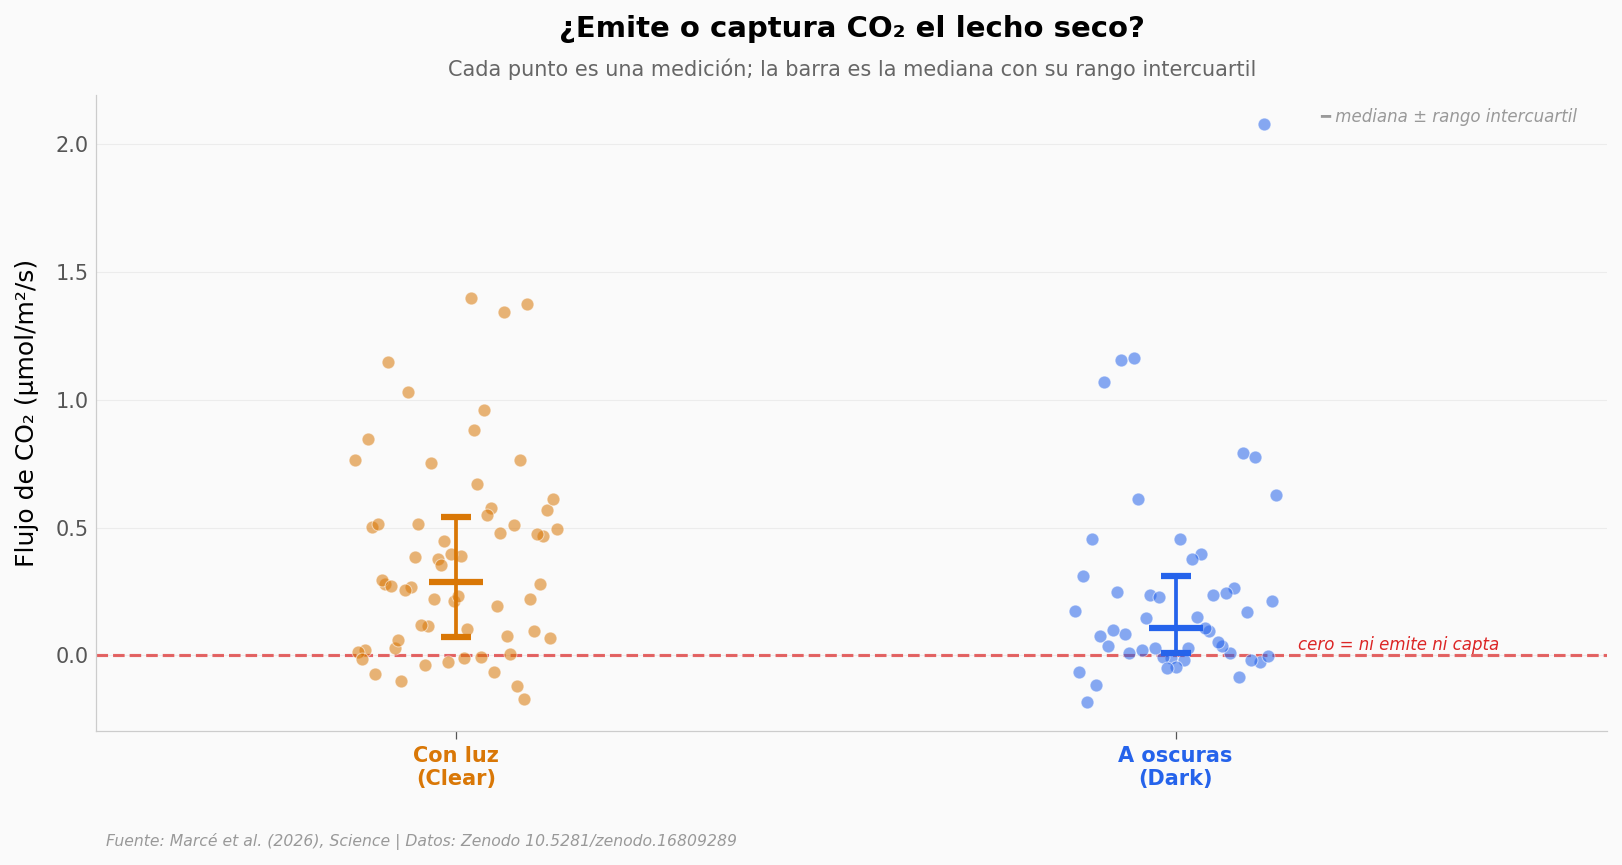

Mediana con luz:  0.286 µmol/m²/s
Mediana a oscuras: 0.108 µmol/m²/s
Mann-Whitney U: p = 0.027 | Cohen's d = 0.30 (efecto pequeño)
Mediciones con emisión neta (> 0): 80%


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

grupos = [
    ('Con luz\n(Clear)', flujo[flujo.condicion == 'Clear'].flujo_co2_umol_m2_s.values, COLOR_REFERENCIA),
    ('A oscuras\n(Dark)', flujo[flujo.condicion == 'Dark'].flujo_co2_umol_m2_s.values, COLOR_DATOS),
]
posiciones = [0, 1]

np.random.seed(42)
for (nombre, vals, color), pos in zip(grupos, posiciones):
    n = len(vals)
    x_strip = np.linspace(pos - 0.14, pos + 0.14, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=38, alpha=0.55,
               edgecolors='white', linewidths=0.5, zorder=5)
    med = np.median(vals)
    q1, q3 = np.percentile(vals, [25, 75])
    ax.errorbar(pos, med, yerr=[[med - q1], [q3 - med]], fmt='_', color=color,
                markersize=26, markeredgewidth=3, capsize=7, capthick=1.5, zorder=6)

# Línea del umbral fuente/sumidero
ax.axhline(y=UMBRAL_FUENTE, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(1.45, 0.02, 'cero = ni emite ni capta', fontsize=8,
        color=COLOR_ALERTA, ha='right', style='italic')

ax.set_xticks(posiciones)
ax.set_xticklabels([g[0] for g in grupos], fontsize=10, fontweight='bold')
for tick, (_, _, color) in zip(ax.get_xticklabels(), grupos):
    tick.set_color(color)

ax.set_title('¿Emite o captura CO₂ el lecho seco?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es una medición; la barra es la mediana con su rango intercuartil',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Flujo de CO₂ (µmol/m²/s)')
ax.set_xlim(-0.5, 1.6)
ax.text(0.98, 0.98, '━ mediana ± rango intercuartil', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='top', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/flujo_co2.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadística de apoyo
clear = flujo[flujo.condicion == 'Clear'].flujo_co2_umol_m2_s
dark = flujo[flujo.condicion == 'Dark'].flujo_co2_umol_m2_s
u, p = stats.mannwhitneyu(clear, dark, alternative='two-sided')
n1, n2 = len(clear), len(dark)
sp = np.sqrt(((n1-1)*clear.var(ddof=1) + (n2-1)*dark.var(ddof=1)) / (n1+n2-2))
d = (clear.mean() - dark.mean()) / sp
pct_positivo = (flujo.flujo_co2_umol_m2_s > 0).mean() * 100
print(f'Mediana con luz:  {clear.median():.3f} µmol/m²/s')
print(f'Mediana a oscuras: {dark.median():.3f} µmol/m²/s')
print(f'Mann-Whitney U: p = {p:.3f} | Cohen\'s d = {d:.2f} (efecto pequeño)')
print(f'Mediciones con emisión neta (> 0): {pct_positivo:.0f}%')

Las dos nubes están casi enteras por encima de cero: el sedimento emite CO₂ **con luz y a oscuras**. La diferencia entre condiciones existe pero es pequeña (Cohen's d ≈ 0,30 — una medida de cuánto se separan dos grupos; 0,30 es poco), así que la lectura no es "de día capta, de noche emite" —es que el lecho es una fuente de carbono en ambos casos. Ocho de cada diez mediciones dan emisión neta.

Si el barro seco emite, la pregunta natural es: ¿y si volvemos a llenar el lago? El equipo modeló varios escenarios de reinundación.

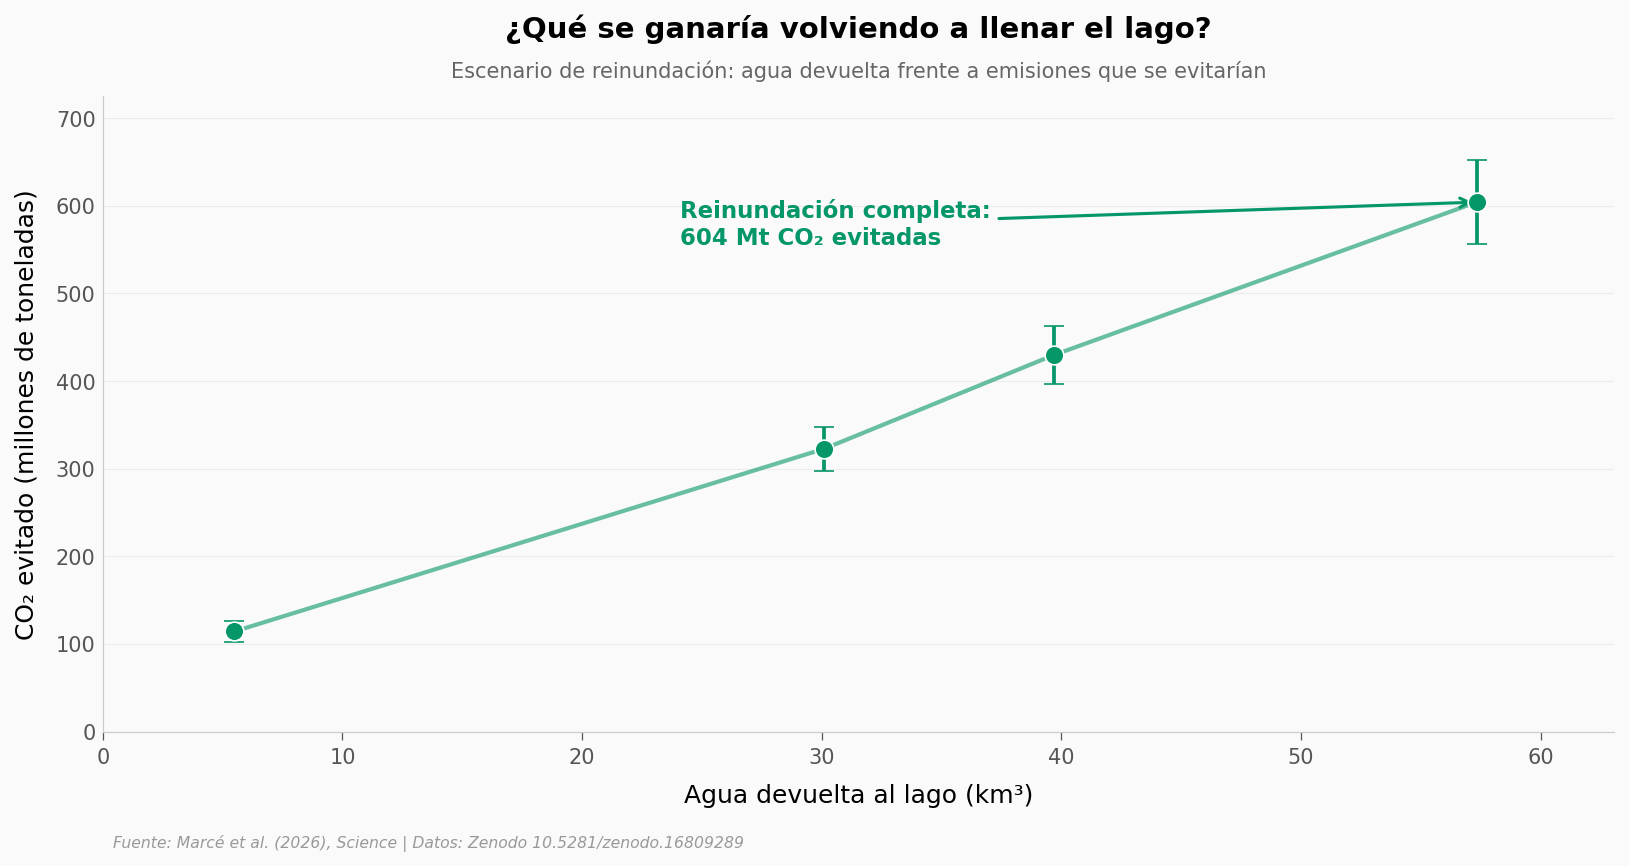

Escenario mínimo: 114 Mt CO₂ evitadas con 5.5 km³
Escenario máximo: 604 Mt CO₂ evitadas con 57.3 km³


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x = reflooding.agua_ahorrada_km3
y = reflooding.co2_evitado_MtCO2

ax.plot(x, y, color=COLOR_SECUNDARIO, linewidth=2, zorder=4, alpha=0.6)
ax.errorbar(x, y, yerr=reflooding.sd_MtCO2, fmt='o', color=COLOR_SECUNDARIO,
            markersize=9, capsize=5, capthick=1.5,
            markeredgecolor='white', markeredgewidth=0.8, zorder=5)

# Destacar el escenario máximo
xmax, ymax = x.iloc[-1], y.iloc[-1]
ax.annotate(f'Reinundación completa:\n{ymax:.0f} Mt CO₂ evitadas',
            xy=(xmax, ymax), xytext=(xmax*0.42, ymax*0.92),
            fontsize=11, fontweight='bold', color=COLOR_SECUNDARIO,
            arrowprops=dict(arrowstyle='->', color=COLOR_SECUNDARIO, lw=1.5))

ax.set_title('¿Qué se ganaría volviendo a llenar el lago?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Escenario de reinundación: agua devuelta frente a emisiones que se evitarían',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Agua devuelta al lago (km³)')
ax.set_ylabel('CO₂ evitado (millones de toneladas)')
ax.set_xlim(0, xmax*1.1)
ax.set_ylim(0, ymax*1.2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/reflooding.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Escenario mínimo: {y.iloc[0]:.0f} Mt CO₂ evitadas con {x.iloc[0]:.1f} km³')
print(f'Escenario máximo: {y.iloc[-1]:.0f} Mt CO₂ evitadas con {x.iloc[-1]:.1f} km³')

## ¿Qué tan lejos de "neutral" está el lecho?

El umbral entre un suelo que captura carbono y uno que lo suelta es el cero. Pongamos todas las mediciones juntas y veamos dónde cae la mayoría respecto a esa línea.

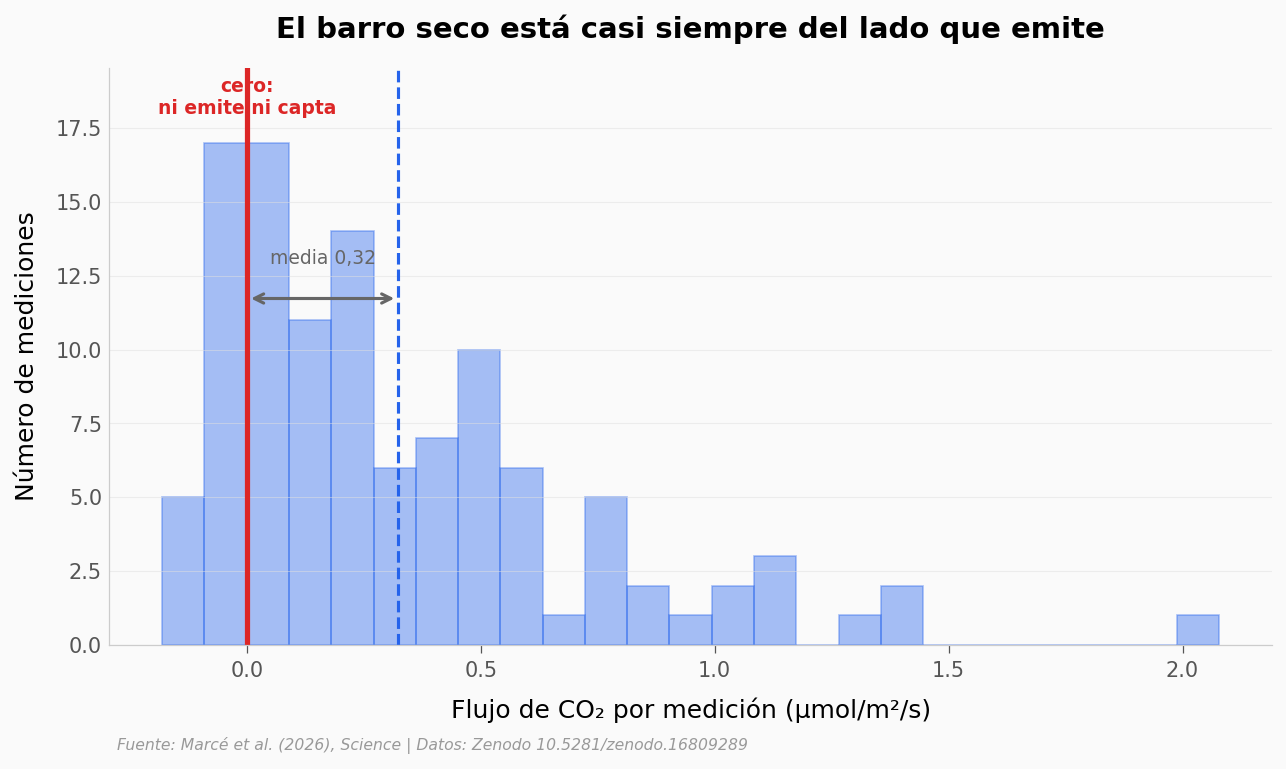

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

data = flujo.flujo_co2_umol_m2_s.values
n, bins, patches = ax.hist(data, bins=25, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

media = data.mean()
ax.axvline(x=UMBRAL_FUENTE, color=COLOR_ALERTA, linewidth=2.5)
ax.axvline(x=media, color=COLOR_DATOS, linewidth=1.5, linestyle='--')

ax.annotate('', xy=(media, y_max*0.6), xytext=(UMBRAL_FUENTE, y_max*0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media + UMBRAL_FUENTE)/2, y_max*0.66,
        f'media {media:.2f}'.replace('.', ','), fontsize=9,
        color='#666666', ha='center')
ax.text(UMBRAL_FUENTE, y_max*0.92, 'cero:\nni emite ni capta', fontsize=9,
        color=COLOR_ALERTA, ha='center', fontweight='bold')

ax.set_title('El barro seco está casi siempre del lado que emite',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Flujo de CO₂ por medición (µmol/m²/s)')
ax.set_ylabel('Número de mediciones')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_flujo.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El lecho expuesto emite CO₂ (es fuente, no sumidero) | ✅ | 111 mediciones en 14 sitios; ~80% con flujo neto positivo, en luz y en oscuridad |
| Emite con luz y a oscuras casi por igual | ✅ | Diferencia estadísticamente detectable (Mann-Whitney p = 0,03) pero de magnitud pequeña (Cohen's d ≈ 0,30). Lo que importa: ambas condiciones son fuente neta de CO₂ |
| Se expusieron ~62.625 km² de lecho hacia 2022 | ✅ | Reconstrucción por teledetección, acumulada desde 1960 |
| Desde 1960 el lecho ha liberado 204 Tg C | ⚠️ | Cifra del paper: integración a escala de sistema (cronosecuencia + área + stocks), no un dato de una sola tabla. La reportamos como la calculó el equipo |
| Reinundar podría evitar ~165 Tg C más | ⚠️ | Escenario modelado (604 Mt CO₂ en reinundación completa), no un resultado observado. Es una propuesta de mitigación |
| La vegetación compensa menos del 1% de lo emitido | ⚠️ | Del abstract; no lo recalculamos con estos CSV |

> **Limitaciones:** el flujo de CO₂ se midió en una sola campaña (septiembre 2022), no a lo largo del año; la trayectoria temporal se **infiere** de una sustitución espacio-por-tiempo (comparar sitios de distinta antigüedad), no de seguir el mismo punto año a año. La cifra de 204 Tg C es una estimación con incertidumbre (±53). La reinundación es un escenario, no algo que haya ocurrido.

## Ahora tú

Los datos están en la carpeta `datos/`. Algunas preguntas para explorar:

1. **¿Los sitios más "calientes" emiten más?** La tabla de flujo trae `temp_sedimento_c`. ¿Hay relación entre temperatura del barro y flujo de CO₂? (pista: `flujo.plot.scatter('temp_sedimento_c', 'flujo_co2_umol_m2_s')`)
2. **¿En qué década se secó más rápido?** Calcula la diferencia de área expuesta por década en `desecacion_area.csv`. (pista: `area.set_index('anio').diff(10)`)
3. **¿Cuánto carbono orgánico guardaba el sedimento?** Mira la distribución de `carbono_organico_pct`. ¿Es simétrica o sesgada? (pista: `sedimento.carbono_organico_pct.median()`)

Spearman ρ = 0.64 (p = 0.000) entre temperatura del sedimento y flujo de CO₂


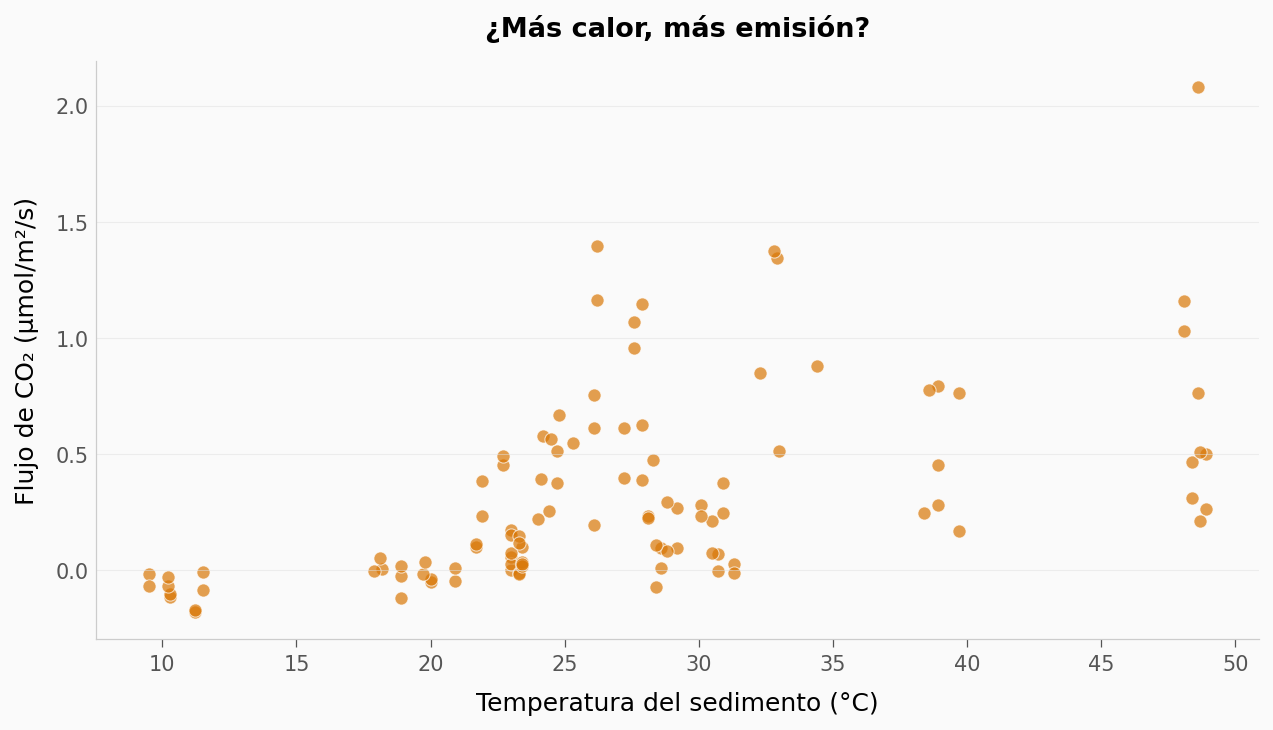

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Emiten más los sedimentos más calientes?
# Probamos correlación de Spearman (no asume normalidad; el flujo está sesgado).

sub = flujo.dropna(subset=['temp_sedimento_c', 'flujo_co2_umol_m2_s'])
rho, p = stats.spearmanr(sub.temp_sedimento_c, sub.flujo_co2_umol_m2_s)
print(f'Spearman ρ = {rho:.2f} (p = {p:.3f}) entre temperatura del sedimento y flujo de CO₂')

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sub.temp_sedimento_c, sub.flujo_co2_umol_m2_s,
           color=COLOR_REFERENCIA, s=40, alpha=0.7,
           edgecolors='white', linewidths=0.5)
ax.set_xlabel('Temperatura del sedimento (°C)')
ax.set_ylabel('Flujo de CO₂ (µmol/m²/s)')
ax.set_title('¿Más calor, más emisión?', fontsize=13, fontweight='bold', pad=12)
plt.show()

---

## Fuentes

**Paper**: [Drying of the Aral Sea reshapes the anthropogenic carbon inventory of Central Asia](https://doi.org/10.1126/science.aeb2344)  
*Science, 2026-07-16*

**Dataset canónico**: [Data & Code for 'Drying of the Aral Sea reshapes the anthropogenic carbon inventory of Central Asia'](https://doi.org/10.5281/zenodo.16809289)  
*Zenodo — flujos de CO₂, área de desecación, escenarios de reinundación y carbono del sedimento*

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [repositorio del Lab](https://github.com/Ciencia-a-Mordiscos/lab).*